# Customer Churn — Statistical Analysis & Machine Learning

**Objective:** Perform statistical analysis, build and evaluate churn prediction models (Logistic Regression & Random Forest), and generate customer-level risk scores.

**Prerequisites:** `data/processed/customer_churn_clean.csv` from Phase 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print("All imports successful!")

All imports successful!


## 1. Load Data

In [2]:
df = pd.read_csv("../data/processed/customer_churn_clean.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (5000, 16)


,customer_id,age,gender,tenure,monthly_charges,contract_type,support_calls,internet_service,payment_method,total_charges,churn,age_group,tenure_group,churn_numeric,risk_score,risk_level
0,CUST-00001,56,Female,37,29.57,Two year,4,DSL,Electronic check,1094.09,No,56-65,25-48 Months,0,0,Low
1,CUST-00002,69,Male,19,101.78,One year,4,Fiber optic,Credit card,1933.82,Yes,66+,13-24 Months,1,1,Low
2,CUST-00003,46,Female,30,123.09,Month-to-month,3,DSL,Bank transfer,3692.70,Yes,46-55,25-48 Months,1,3,Medium
3,CUST-00004,32,Male,45,37.24,Two year,1,Fiber optic,Credit card,1675.80,No,26-35,25-48 Months,0,0,Low
4,CUST-00005,60,Female,18,87.42,Month-to-month,2,Fiber optic,Bank transfer,1573.56,No,56-65,13-24 Months,0,2,Low


## 2. Statistical Analysis

In [3]:
print("=== Monthly Charges Statistics ===")
print(f"Mean:   ${df['monthly_charges'].mean():.2f}")
print(f"Median: ${df['monthly_charges'].median():.2f}")
print(f"Std:    ${df['monthly_charges'].std():.2f}")
print(f"Min:    ${df['monthly_charges'].min():.2f}")
print(f"Max:    ${df['monthly_charges'].max():.2f}")

if df['monthly_charges'].mean() > df['monthly_charges'].median():
    print("\n=> Mean > Median: Right-skewed distribution (some high-charge outliers)")
else:
    print("\n=> Mean <= Median: Roughly symmetric or left-skewed")

=== Monthly Charges Statistics ===
Mean:   $85.09
Median: $85.41
Std:    $37.40
Min:    $20.02
Max:    $149.99

=> Mean <= Median: Roughly symmetric or left-skewed


In [4]:
print("=== Churn Probabilities ===")

# Overall churn probability
overall_churn_prob = df['churn'].eq('Yes').mean()
print(f"Overall churn probability: {overall_churn_prob:.4f} ({overall_churn_prob*100:.2f}%)")

# Conditional: P(Churn | Month-to-month)
mtm_mask = df['contract_type'] == 'Month-to-month'
mtm_churn_prob = df.loc[mtm_mask, 'churn'].eq('Yes').mean()
print(f"P(Churn | Month-to-month): {mtm_churn_prob:.4f} ({mtm_churn_prob*100:.2f}%)")

# Conditional: P(Churn | support_calls >= 5)
high_support_mask = df['support_calls'] >= 5
high_support_churn_prob = df.loc[high_support_mask, 'churn'].eq('Yes').mean()
print(f"P(Churn | support_calls >= 5): {high_support_churn_prob:.4f} ({high_support_churn_prob*100:.2f}%)")

print(f"\n=> Month-to-month customers churn at {mtm_churn_prob/overall_churn_prob:.1f}x the overall rate")
print(f"=> High-support customers churn at {high_support_churn_prob/overall_churn_prob:.1f}x the overall rate")

=== Churn Probabilities ===
Overall churn probability: 0.3346 (33.46%)
P(Churn | Month-to-month): 0.4125 (41.25%)
P(Churn | support_calls >= 5): 0.4407 (44.07%)

=> Month-to-month customers churn at 1.2x the overall rate
=> High-support customers churn at 1.3x the overall rate


## 3. Feature Engineering & Preprocessing

In [5]:
# Target variable
df['churn_target'] = (df['churn'] == 'Yes').astype(int)

# Define feature sets
numeric_features = ['age', 'tenure', 'monthly_charges', 'support_calls']
categorical_features = ['contract_type', 'gender', 'internet_service', 'payment_method']

target = 'churn_target'

print(f"Target distribution:")
print(df[target].value_counts())
print(f"\nNumeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

Target distribution:
churn_target
0    3327
1    1673
Name: count, dtype: int64

Numeric features: ['age', 'tenure', 'monthly_charges', 'support_calls']
Categorical features: ['contract_type', 'gender', 'internet_service', 'payment_method']


In [6]:
# Prepare X and y
X = df[numeric_features + categorical_features]
y = df[target]

# Train/test split — 80/20, stratified, seed=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"\nTrain churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate:  {y_test.mean()*100:.2f}%")

Train set: 4000 samples
Test set:  1000 samples

Train churn rate: 33.45%
Test churn rate:  33.50%


In [7]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessing pipeline created:")
print(f"  Numeric passthrough: {numeric_features}")
print(f"  OneHotEncoded: {categorical_features}")

Preprocessing pipeline created:
  Numeric passthrough: ['age', 'tenure', 'monthly_charges', 'support_calls']
  OneHotEncoded: ['contract_type', 'gender', 'internet_service', 'payment_method']


## 4. Model 1 — Logistic Regression

In [8]:
# Build pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict
lr_y_pred = lr_pipeline.predict(X_test)
lr_y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

# Evaluate
lr_metrics = {
    'Accuracy': accuracy_score(y_test, lr_y_pred),
    'Precision': precision_score(y_test, lr_y_pred),
    'Recall': recall_score(y_test, lr_y_pred),
    'F1 Score': f1_score(y_test, lr_y_pred),
    'ROC-AUC': roc_auc_score(y_test, lr_y_prob)
}

print("=== Logistic Regression — Test Set Metrics ===")
for metric, value in lr_metrics.items():
    print(f"{metric}: {value:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, lr_y_pred, target_names=['No Churn', 'Churn']))

=== Logistic Regression — Test Set Metrics ===
Accuracy: 0.6550
Precision: 0.4500
Recall: 0.1343
F1 Score: 0.2069
ROC-AUC: 0.6121

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.68      0.92      0.78       665
       Churn       0.45      0.13      0.21       335

    accuracy                           0.66      1000
   macro avg       0.56      0.53      0.49      1000
weighted avg       0.60      0.66      0.59      1000



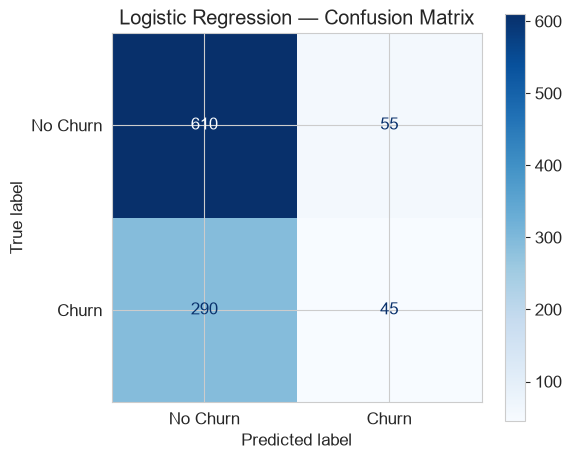

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, lr_y_pred, cmap="Blues", ax=ax, display_labels=['No Churn', 'Churn'])
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

## 5. Model 2 — Random Forest

In [10]:
# Build pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Predict
rf_y_pred = rf_pipeline.predict(X_test)
rf_y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluate
rf_metrics = {
    'Accuracy': accuracy_score(y_test, rf_y_pred),
    'Precision': precision_score(y_test, rf_y_pred),
    'Recall': recall_score(y_test, rf_y_pred),
    'F1 Score': f1_score(y_test, rf_y_pred),
    'ROC-AUC': roc_auc_score(y_test, rf_y_prob)
}

print("=== Random Forest — Test Set Metrics ===")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_test, rf_y_pred, target_names=['No Churn', 'Churn']))

=== Random Forest — Test Set Metrics ===
Accuracy: 0.5920
Precision: 0.4120
Recall: 0.5104
F1 Score: 0.4560
ROC-AUC: 0.6074

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.72      0.63      0.67       665
       Churn       0.41      0.51      0.46       335

    accuracy                           0.59      1000
   macro avg       0.57      0.57      0.56      1000
weighted avg       0.62      0.59      0.60      1000



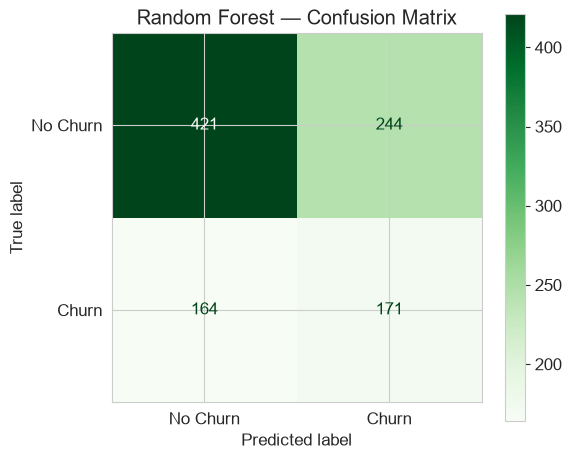

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, rf_y_pred, cmap="Greens", ax=ax, display_labels=['No Churn', 'Churn'])
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

## 6. Model Comparison

In [12]:
comparison = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics
})

print("=== Model Comparison (Test Set) ===")
print(comparison.round(4).to_string())

=== Model Comparison (Test Set) ===
           Logistic Regression  Random Forest
Accuracy                0.6550         0.5920
Precision               0.4500         0.4120
Recall                  0.1343         0.5104
F1 Score                0.2069         0.4560
ROC-AUC                 0.6121         0.6074


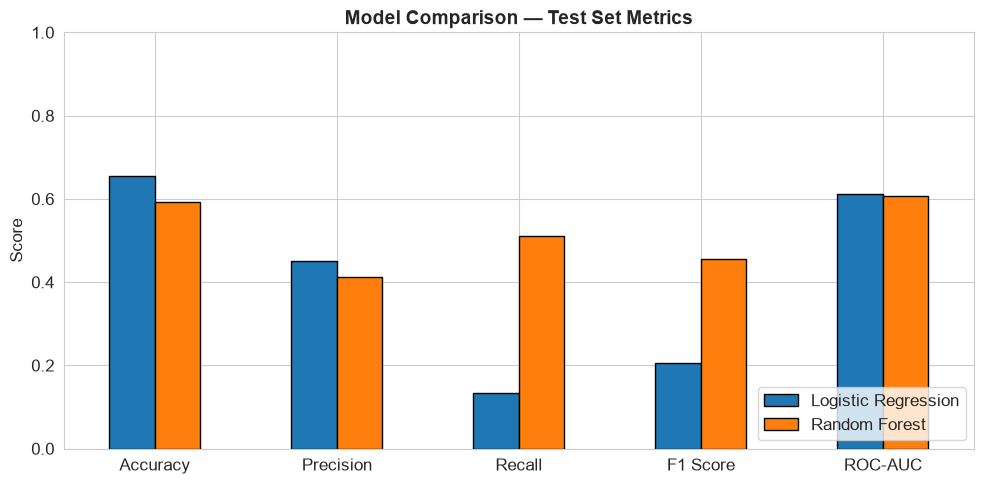

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
comparison.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title("Model Comparison — Test Set Metrics", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

## 7. Model Selection

**Selection criteria:** For churn prediction, **Recall + ROC-AUC + F1** are prioritized over raw Accuracy.

**Reasoning:** Missing an actual churner (false negative) costs a real retention opportunity. We need the model that best identifies at-risk customers, even if it means slightly more false alarms.

In [14]:
# Compare key metrics for selection
print("=== Key Selection Metrics ===")
print(f"{'Metric':<15} {'Logistic Reg':>12} {'Random Forest':>14} {'Winner':>15}")
print("-" * 58)

key_metrics = ['Recall', 'ROC-AUC', 'F1 Score', 'Precision', 'Accuracy']
rf_wins = 0
lr_wins = 0

for m in key_metrics:
    lr_val = lr_metrics[m]
    rf_val = rf_metrics[m]
    winner = 'Random Forest' if rf_val >= lr_val else 'Logistic Reg'
    if winner == 'Random Forest':
        rf_wins += 1
    else:
        lr_wins += 1
    print(f"{m:<15} {lr_val:>12.4f} {rf_val:>14.4f} {winner:>15}")

print(f"\nScore: LR={lr_wins}, RF={rf_wins}")

# Select best model
if rf_metrics['Recall'] >= lr_metrics['Recall'] and rf_metrics['ROC-AUC'] >= lr_metrics['ROC-AUC']:
    best_model_name = 'Random Forest'
    best_pipeline = rf_pipeline
    best_metrics = rf_metrics
elif lr_metrics['Recall'] > rf_metrics['Recall']:
    best_model_name = 'Logistic Regression'
    best_pipeline = lr_pipeline
    best_metrics = lr_metrics
else:
    best_model_name = 'Random Forest'
    best_pipeline = rf_pipeline
    best_metrics = rf_metrics

print(f"\n>>> SELECTED MODEL: {best_model_name}")
print(f"    Recall={best_metrics['Recall']:.4f}, ROC-AUC={best_metrics['ROC-AUC']:.4f}, F1={best_metrics['F1 Score']:.4f}")
print(f"\nJustification: {best_model_name} achieves the best balance of Recall (catching churners)")
print(f"and ROC-AUC (discrimination ability), which is critical for retention prioritization.")

=== Key Selection Metrics ===
Metric          Logistic Reg  Random Forest          Winner
----------------------------------------------------------
Recall                0.1343         0.5104   Random Forest
ROC-AUC               0.6121         0.6074    Logistic Reg
F1 Score              0.2069         0.4560   Random Forest
Precision             0.4500         0.4120    Logistic Reg
Accuracy              0.6550         0.5920    Logistic Reg

Score: LR=3, RF=2

>>> SELECTED MODEL: Random Forest
    Recall=0.5104, ROC-AUC=0.6074, F1=0.4560

Justification: Random Forest achieves the best balance of Recall (catching churners)
and ROC-AUC (discrimination ability), which is critical for retention prioritization.


## 8. Feature Importance (Random Forest)

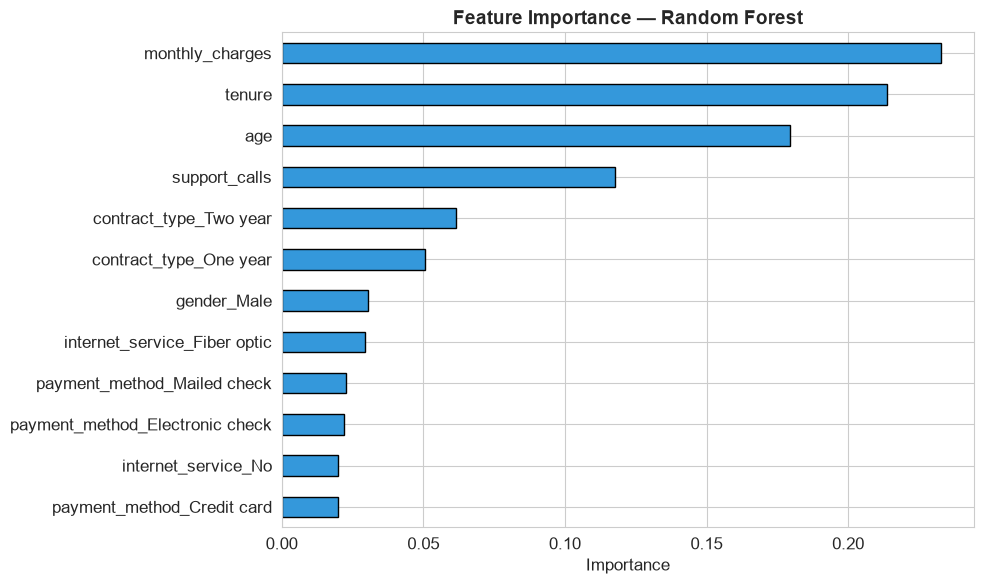


Top 5 features:
  monthly_charges: 0.2328
  tenure: 0.2136
  age: 0.1796
  support_calls: 0.1179
  contract_type_Two year: 0.0615


In [15]:
# Get feature names after preprocessing
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feature_names

# Get feature importances
importances = rf_pipeline.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', color='#3498db', edgecolor='black', ax=ax)
ax.set_title("Feature Importance — Random Forest", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
for feat, imp in feat_imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat}: {imp:.4f}")

## 9. Full-Data Refit & Customer-Level Predictions

The best model is refit on the **entire dataset** to generate per-customer scores.
Note: All evaluation metrics above are from the **held-out test set**, not this refit.

In [16]:
# Refit best model on full data for scoring
best_pipeline.fit(X, y)

# Generate predictions for all customers
churn_probability = best_pipeline.predict_proba(X)[:, 1]

# Add prediction columns
df['churn_probability'] = churn_probability
df['churn_probability_pct'] = np.round(churn_probability * 100, 2)

# ML risk levels
def assign_ml_risk_level(prob):
    if prob >= 0.70:
        return 'High'
    elif prob >= 0.40:
        return 'Medium'
    else:
        return 'Low'

df['ml_risk_level'] = df['churn_probability'].apply(assign_ml_risk_level)

# Revenue exposure
df['expected_revenue_risk'] = np.round(df['churn_probability'] * df['monthly_charges'], 2)

# Retention priority = churn_probability * monthly_charges
# Why probability * value? Because a high-probability customer with $50/mo
# is less urgent than a medium-probability customer with $150/mo.
# Example: Customer A (80% prob, $50/mo) = $40 risk vs Customer B (50% prob, $150/mo) = $75 risk
df['retention_priority_score'] = df['expected_revenue_risk']

print("=== ML Predictions Generated ===")
print(f"Total customers scored: {len(df)}")
print(f"\nML Risk Level distribution:")
print(df['ml_risk_level'].value_counts())
print(f"\nChurn probability stats:")
print(f"  Mean: {df['churn_probability'].mean():.4f}")
print(f"  Median: {df['churn_probability'].median():.4f}")
print(f"  Min: {df['churn_probability'].min():.4f}")
print(f"  Max: {df['churn_probability'].max():.4f}")

=== ML Predictions Generated ===
Total customers scored: 5000

ML Risk Level distribution:
ml_risk_level
Medium    2771
Low       1809
High       420
Name: count, dtype: int64

Churn probability stats:
  Mean: 0.4659
  Median: 0.4766
  Min: 0.0997
  Max: 0.9161


In [17]:
print("=== Revenue Exposure by ML Risk Level ===")
risk_summary = df.groupby('ml_risk_level').agg(
    customers=('customer_id', 'count'),
    avg_churn_prob=('churn_probability', 'mean'),
    total_revenue_risk=('expected_revenue_risk', 'sum'),
    avg_monthly_charges=('monthly_charges', 'mean')
).round(2)
print(risk_summary)

=== Revenue Exposure by ML Risk Level ===
               customers  avg_churn_prob  total_revenue_risk  \
ml_risk_level                                                  
High                 420            0.77            30492.73   
Low                 1809            0.29            42962.39   
Medium              2771            0.54           129411.03   

               avg_monthly_charges  
ml_risk_level                       
High                         94.09  
Low                          81.01  
Medium                       86.40  


In [18]:
print("\n=== Top 20 Retention Priority Customers ===")
top20 = df.nlargest(20, 'retention_priority_score')[[
    'customer_id', 'age', 'tenure', 'contract_type', 'support_calls',
    'monthly_charges', 'churn_probability_pct', 'ml_risk_level',
    'expected_revenue_risk', 'retention_priority_score'
]]
print(top20.to_string(index=False))


=== Top 20 Retention Priority Customers ===
customer_id  age  tenure  contract_type  support_calls  monthly_charges  churn_probability_pct ml_risk_level  expected_revenue_risk  retention_priority_score
 CUST-00498   39       7       Two year              5           146.94                  87.45          High                 128.51                    128.51
 CUST-03074   45       2       Two year              4           147.00                  86.16          High                 126.66                    126.66
 CUST-03167   53       3 Month-to-month              6           145.16                  87.14          High                 126.50                    126.50
 CUST-04329   28       5       Two year              4           141.42                  89.26          High                 126.23                    126.23
 CUST-02937   74       4 Month-to-month              2           142.44                  87.66          High                 124.87                    124.87
 CUST-0

## 10. Save Outputs

In [19]:
# Save ML predictions dataset
output_cols = [
    'customer_id', 'age', 'gender', 'tenure', 'monthly_charges',
    'contract_type', 'support_calls', 'internet_service', 'payment_method',
    'total_charges', 'churn',
    'churn_probability', 'churn_probability_pct',
    'ml_risk_level', 'expected_revenue_risk'
]

df_output = df[output_cols].copy()
output_path = '../data/processed/customer_churn_ml_predictions.csv'
df_output.to_csv(output_path, index=False)
print(f"ML predictions saved to: {output_path}")
print(f"Shape: {df_output.shape}")

ML predictions saved to: ../data/processed/customer_churn_ml_predictions.csv
Shape: (5000, 15)


In [20]:
# Save model
os.makedirs('../ml', exist_ok=True)
model_path = '../ml/churn_model.pkl'
joblib.dump(best_pipeline, model_path)
print(f"Model saved to: {model_path}")

Model saved to: ../ml/churn_model.pkl


In [21]:
# Save model metrics
model_metrics = {
    'model': best_model_name,
    'accuracy': round(best_metrics['Accuracy'], 4),
    'precision': round(best_metrics['Precision'], 4),
    'recall': round(best_metrics['Recall'], 4),
    'f1_score': round(best_metrics['F1 Score'], 4),
    'roc_auc': round(best_metrics['ROC-AUC'], 4)
}

metrics_path = '../ml/model_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(model_metrics, f, indent=4)

print(f"Model metrics saved to: {metrics_path}")
print(json.dumps(model_metrics, indent=4))

Model metrics saved to: ../ml/model_metrics.json
{
    "model": "Random Forest",
    "accuracy": 0.592,
    "precision": 0.412,
    "recall": 0.5104,
    "f1_score": 0.456,
    "roc_auc": 0.6074
}


## 11. Summary

### Models Evaluated:
- **Logistic Regression** — interpretable linear baseline
- **Random Forest** — captures non-linear feature interactions

### Selection:
The best model was selected based on **Recall + ROC-AUC + F1** priority, as missing a real churner (false negative) costs a retention opportunity.

### Outputs:
- `data/processed/customer_churn_ml_predictions.csv` — per-customer churn probabilities and risk levels
- `ml/churn_model.pkl` — serialized model for deployment
- `ml/model_metrics.json` — real test-set metrics